## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

os.chdir("/home/patrick/ansermodelling")

from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train
from anser import *


## Dataset

In [3]:
coils_global = build_field_generator(consts.N_turns,consts.l,consts.w,consts.s,consts.z_thick,consts.centres,consts.rotations)
dataset = AnserDataset("data/dataset.npz")

### Spatial Distribution

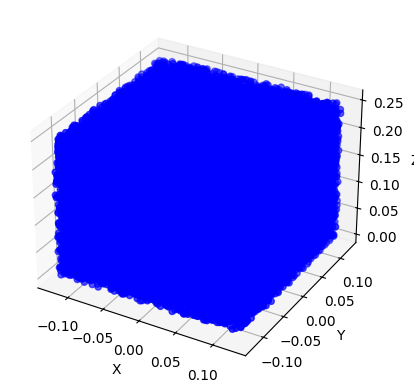

In [4]:
positions = dataset.y[:,:3]

# Create a new figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create a scatter plot
ax.scatter(positions[:,0], positions[:,1], positions[:,2], c='blue', marker='o')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()

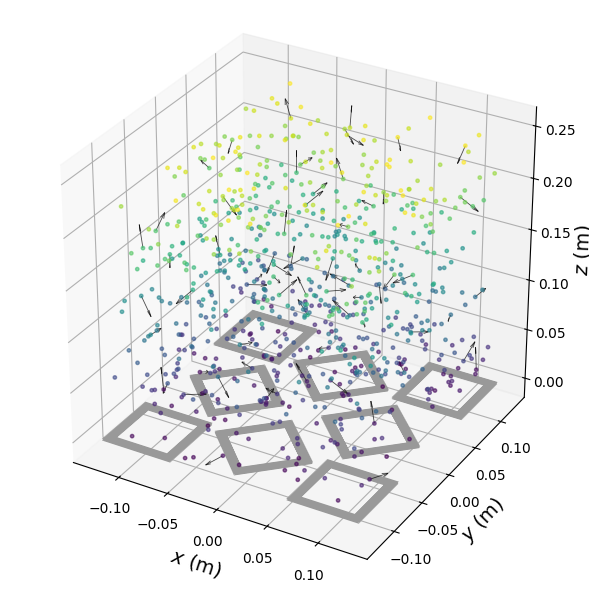

In [5]:

rng = np.random.default_rng(0)
idx = rng.choice(len(dataset.y), size=800, replace=False)
poses = dataset.y[idx].numpy()
pos, nrm = poses[:, :3], poses[:, 3:]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# coil filaments
for i in range(coils_global.shape[0]):
    ax.plot3D(*coils_global[i].T, linewidth=0.4, color='0.6', zorder=1)

# sampled poses, coloured by height
sc = ax.scatter(*pos.T, c=pos[:, 2], cmap='viridis', s=6, alpha=0.6, zorder=2)

# orientation quivers on a sparse subset
q = slice(None, None, 12)
ax.quiver(*pos[q].T, *nrm[q].T, length=0.02, linewidth=0.6,
          color='k', alpha=0.7, normalize=True)

ax.set_xlabel(r'$x$ (m)', fontsize=14)
ax.set_ylabel(r'$y$ (m)', fontsize=14)
ax.set_zlabel(r'$z$ (m)', fontsize=14)
ax.set_box_aspect([1, 1, 1])
fig.tight_layout()
fig.savefig("report/figs/sampled_poses.png")

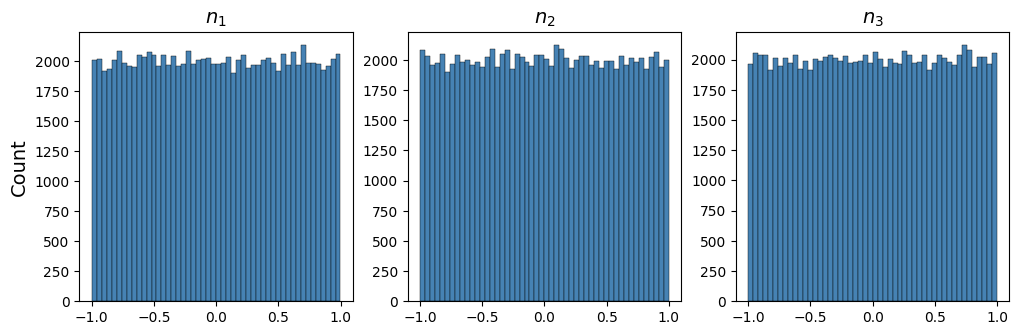

In [8]:
n_1 = dataset.y[:, 3]
n_2 = dataset.y[:, 4]
n_3 = dataset.y[:, 5]


fig, axes = plt.subplots(1, 3, figsize = (12,3.5))

axes[0].hist(n_1, bins=50, color = "steelblue", edgecolor = "black", linewidth = 0.3)
axes[0].set_title(r"$n_1$", fontsize=14)
axes[1].hist(n_2, bins=50, color = "steelblue", edgecolor = "black", linewidth = 0.3)
axes[1].set_title(r"$n_2$", fontsize=14)
axes[2].hist(n_3, bins=50, color = "steelblue", edgecolor = "black", linewidth = 0.3)
axes[2].set_title(r"$n_3$", fontsize=14)

axes[0].set_ylabel("Count", fontsize=14)
plt.savefig("report/figs/orientation_sampling.png")
plt.show()

Distrubtion of Fluxes

0.006126064
20.029528


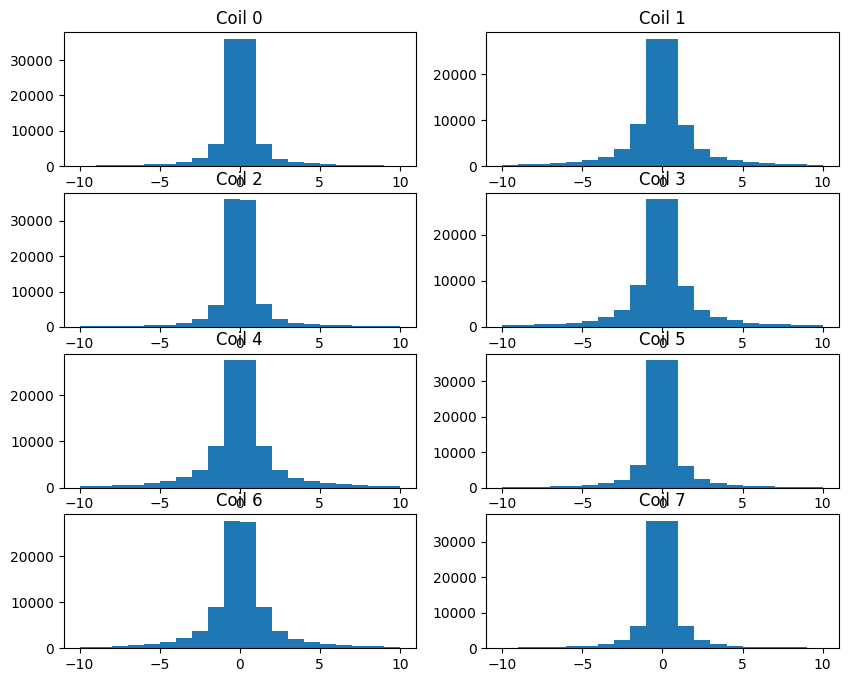

In [6]:
fluxes = dataset.x.numpy()
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

print(np.mean(fluxes))
print(np.std(fluxes))

for ax, i in zip(axes.flat, range(8)):
    ax.hist(fluxes[:, i], bins=20,range=(-10, 10))
    ax.set_title(f"Coil {i}")
plt.show()